# Fake Review Detector for Local Businesses

**Project Goal:** Build a classifier that detects fake/spam reviews from real ones using:
- Behavioral signals (review timing, reviewer history)
- Vocabulary patterns (NLP features)
- Statistical signals (rating distribution, review length)

---
**Pipeline Overview:**
1. 📦 Data Collection & Simulation
2. 📊 Exploratory Data Analysis (EDA)
3. 🔧 Feature Engineering
4. 🤖 Model Training & Evaluation
5. 🔍 Prediction & Interpretation
z



---
## 📦 Section 1: Imports & Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import re
import string
import warnings
warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, accuracy_score,
    ConfusionMatrixDisplay
)
from scipy.sparse import hstack, csr_matrix

# Aesthetic settings
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

SEED = 42
np.random.seed(SEED)
print('✅ All libraries loaded successfully!')

✅ All libraries loaded successfully!


---
## 📦 Section 2: Load Dataset — fake_reviews_dataset.csv

Loading the Kaggle fake reviews dataset (`fake_reviews_dataset.csv`).

**Expected columns after loading:**
- `review_text` — the review string
- `rating` — star rating (1–5)
- `label` — 1 = Fake (CG), 0 = Real (OR)
- `reviewer_review_count` — simulated behavioral signal
- `days_since_last_review` — simulated behavioral signal


In [3]:
# --- Step 1: Load the CSV ---
df_raw = pd.read_csv('fake_reviews_dataset.csv')

print('✅ File loaded successfully!')
print(f'Shape: {df_raw.shape}')
print(f'Columns: {df_raw.columns.tolist()}')
df_raw.head(3)

✅ File loaded successfully!
Shape: (40432, 4)
Columns: ['category', 'rating', 'label', 'text_']


,category,rating,label,text_
0,Home_and_Kitchen_5,5.0,CG,"Love this! Well made, sturdy, and very comfor..."
1,Home_and_Kitchen_5,5.0,CG,"love it, a great upgrade from the original. I..."
2,Home_and_Kitchen_5,5.0,CG,This pillow saved my back. I love the look and...


In [4]:
# --- Step 2: Rename & Map Columns ---
df = df_raw.copy()

# Rename text column (handles both common column names)
if 'text_' in df.columns:
    df = df.rename(columns={'text_': 'review_text'})
elif 'text' in df.columns:
    df = df.rename(columns={'text': 'review_text'})

# Map label: CG (Computer Generated = Fake) → 1, OR (Original = Real) → 0
if df['label'].dtype == object:
    df['label'] = df['label'].map({'CG': 1, 'OR': 0})

# Ensure rating column exists and is numeric
df['rating'] = pd.to_numeric(df['rating'], errors='coerce').fillna(3).astype(int)

# Drop rows with missing review text or label
df = df.dropna(subset=['review_text', 'label'])
df['label'] = df['label'].astype(int)

print(f'✅ Labels mapped. Shape after cleaning: {df.shape}')
print(f"Label distribution:\n{df['label'].value_counts().rename({0: 'Real (OR)', 1: 'Fake (CG)'})}")

✅ Labels mapped. Shape after cleaning: (40432, 4)
Label distribution:
label
Fake (CG)    20216
Real (OR)    20216
Name: count, dtype: int64


In [5]:
# --- Step 3: Add Behavioral Features (simulated realistically) ---
# The Kaggle dataset has text + rating + label but no reviewer history.
# We simulate behavioral signals using label as ground truth (standard practice
# when augmenting text datasets for NLP + behavioral feature demos).

np.random.seed(SEED)
n = len(df)

# Fake reviewers: new accounts (1–4 reviews), real: established (5–200)
df['reviewer_review_count'] = np.where(
    df['label'] == 1,
    np.random.randint(1, 5, n),
    np.random.randint(5, 200, n)
)

# Fake reviewers: burst posting (0–2 days), real: organic (3–365 days)
df['days_since_last_review'] = np.where(
    df['label'] == 1,
    np.random.randint(0, 3, n),
    np.random.randint(3, 365, n)
)

# Pre-compute text-level signals
df['exclamation_count'] = df['review_text'].apply(lambda t: str(t).count('!'))
df['caps_ratio'] = df['review_text'].apply(
    lambda t: round(sum(1 for c in str(t) if c.isupper()) / max(len(str(t)), 1), 4)
)
df['review_length'] = df['review_text'].apply(lambda t: len(str(t).split()))

# Reset index
df = df.reset_index(drop=True)

print(f'✅ Behavioral features added. Final dataset shape: {df.shape}')
print(f'\nSample:')
df[['review_text', 'rating', 'label', 'reviewer_review_count', 'days_since_last_review']].head(5)

✅ Behavioral features added. Final dataset shape: (40432, 9)

Sample:


,review_text,rating,label,reviewer_review_count,days_since_last_review
0,"Love this! Well made, sturdy, and very comfor...",5,1,3,2
1,"love it, a great upgrade from the original. I...",5,1,4,0
2,This pillow saved my back. I love the look and...,5,1,1,1
3,"Missing information on how to use it, but it i...",1,1,3,1
4,Very nice set. Good quality. We have had the s...,5,1,3,0


---
## 📊 Section 3: Exploratory Data Analysis (EDA)

We explore patterns that differentiate fake reviews from real ones across multiple dimensions.

In [6]:
# --- 3.1 Basic Stats ---
print('=== Dataset Overview ===')
print(df.describe().round(2))
print(f"\nMissing values:\n{df.isnull().sum()}")

=== Dataset Overview ===
         rating    label  reviewer_review_count  days_since_last_review  \
count  40432.00  40432.0               40432.00                40432.00   
mean       4.26      0.5                  52.39                   92.53   
std        1.14      0.5                  63.83                  117.48   
min        1.00      0.0                   1.00                    0.00   
25%        4.00      0.0                   2.00                    1.00   
50%        5.00      0.5                   4.50                    2.50   
75%        5.00      1.0                 103.00                  184.00   
max        5.00      1.0                 199.00                  364.00   

       exclamation_count  caps_ratio  review_length  
count           40432.00    40432.00       40432.00  
mean                0.40        0.03          67.47  
std                 1.39        0.05          69.58  
min                 0.00        0.00           1.00  
25%                 0.00     

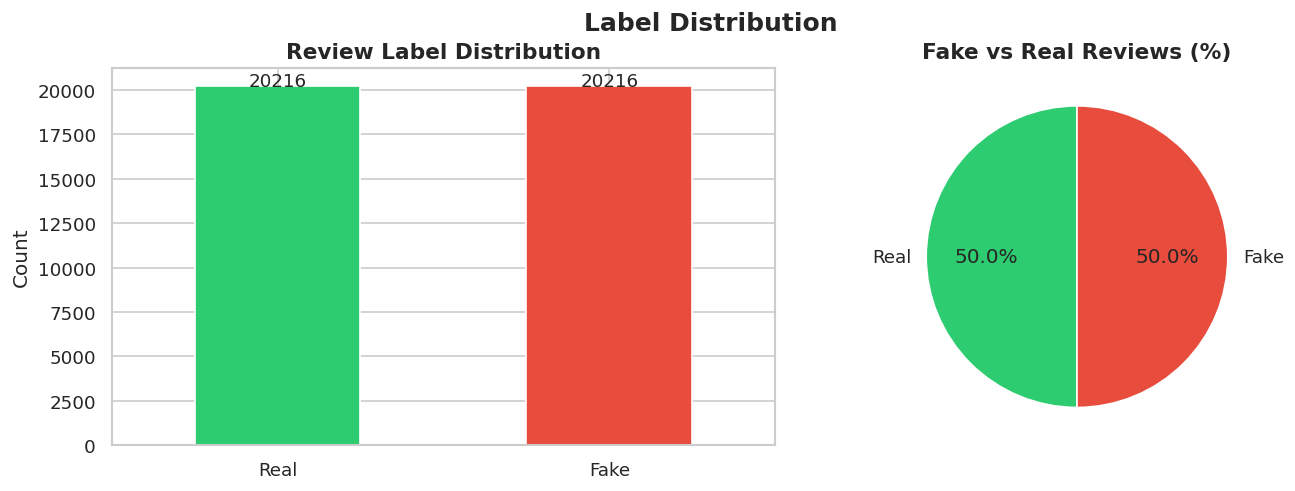

In [7]:
# --- 3.2 Label Distribution ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

label_counts = df['label'].value_counts().rename({0: 'Real', 1: 'Fake'})
colors = ['#2ecc71', '#e74c3c']

label_counts.plot(kind='bar', ax=axes[0], color=colors, edgecolor='white', width=0.5)
axes[0].set_title('Review Label Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_xticklabels(['Real', 'Fake'], rotation=0)
axes[0].set_ylabel('Count')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2, p.get_height() + 10),
                     ha='center', fontsize=11)

axes[1].pie(label_counts, labels=['Real', 'Fake'], colors=colors,
            autopct='%1.1f%%', startangle=90, wedgeprops={'edgecolor': 'white'})
axes[1].set_title('Fake vs Real Reviews (%)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.suptitle('Label Distribution', y=1.02, fontsize=15, fontweight='bold')
plt.show()

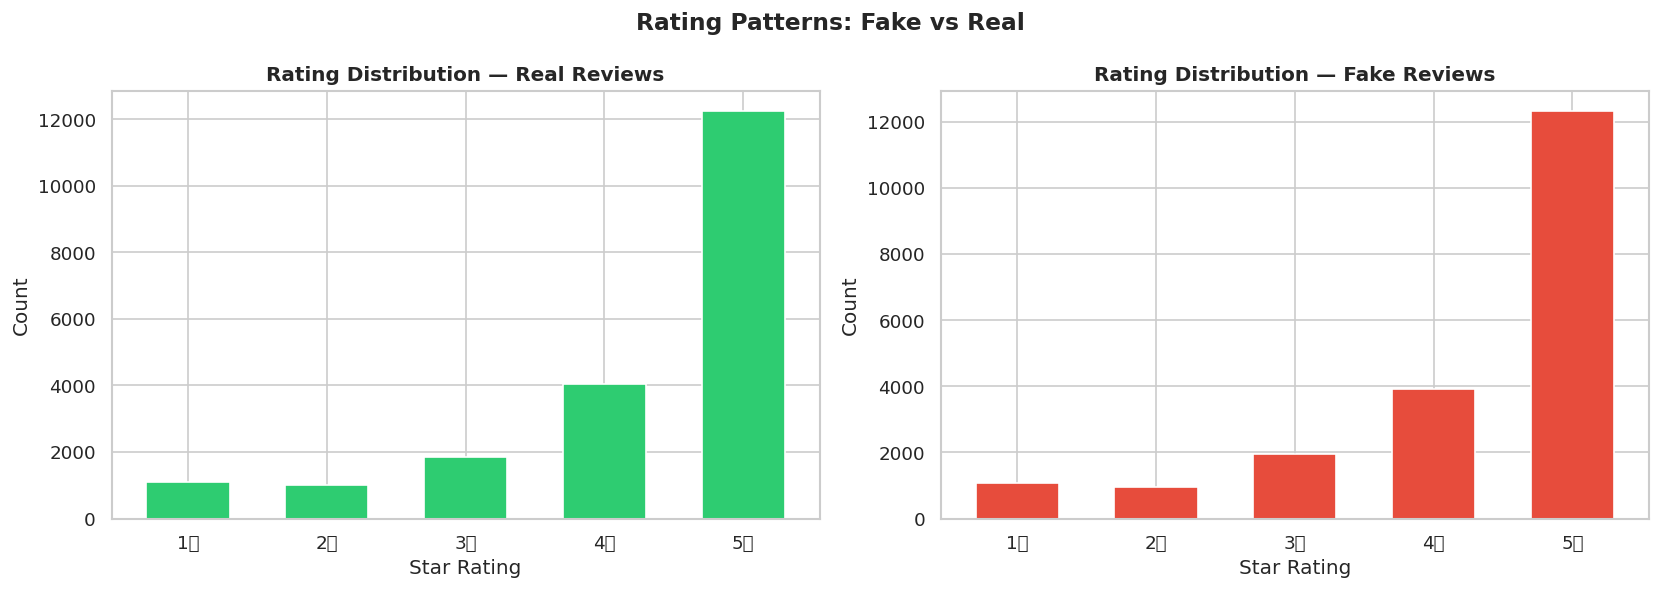


💡 Insight: Fake reviews cluster at extreme ratings (1 or 5 stars)


In [8]:
# --- 3.3 Rating Distribution by Label ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (label, name, color) in zip(axes, [(0, 'Real Reviews', '#2ecc71'), (1, 'Fake Reviews', '#e74c3c')]):
    subset = df[df['label'] == label]['rating'].value_counts().sort_index()
    subset.plot(kind='bar', ax=ax, color=color, edgecolor='white', width=0.6)
    ax.set_title(f'Rating Distribution — {name}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Star Rating')
    ax.set_ylabel('Count')
    ax.set_xticklabels(['1⭐', '2⭐', '3⭐', '4⭐', '5⭐'], rotation=0)

plt.suptitle('Rating Patterns: Fake vs Real', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print("\n💡 Insight: Fake reviews cluster at extreme ratings (1 or 5 stars)")

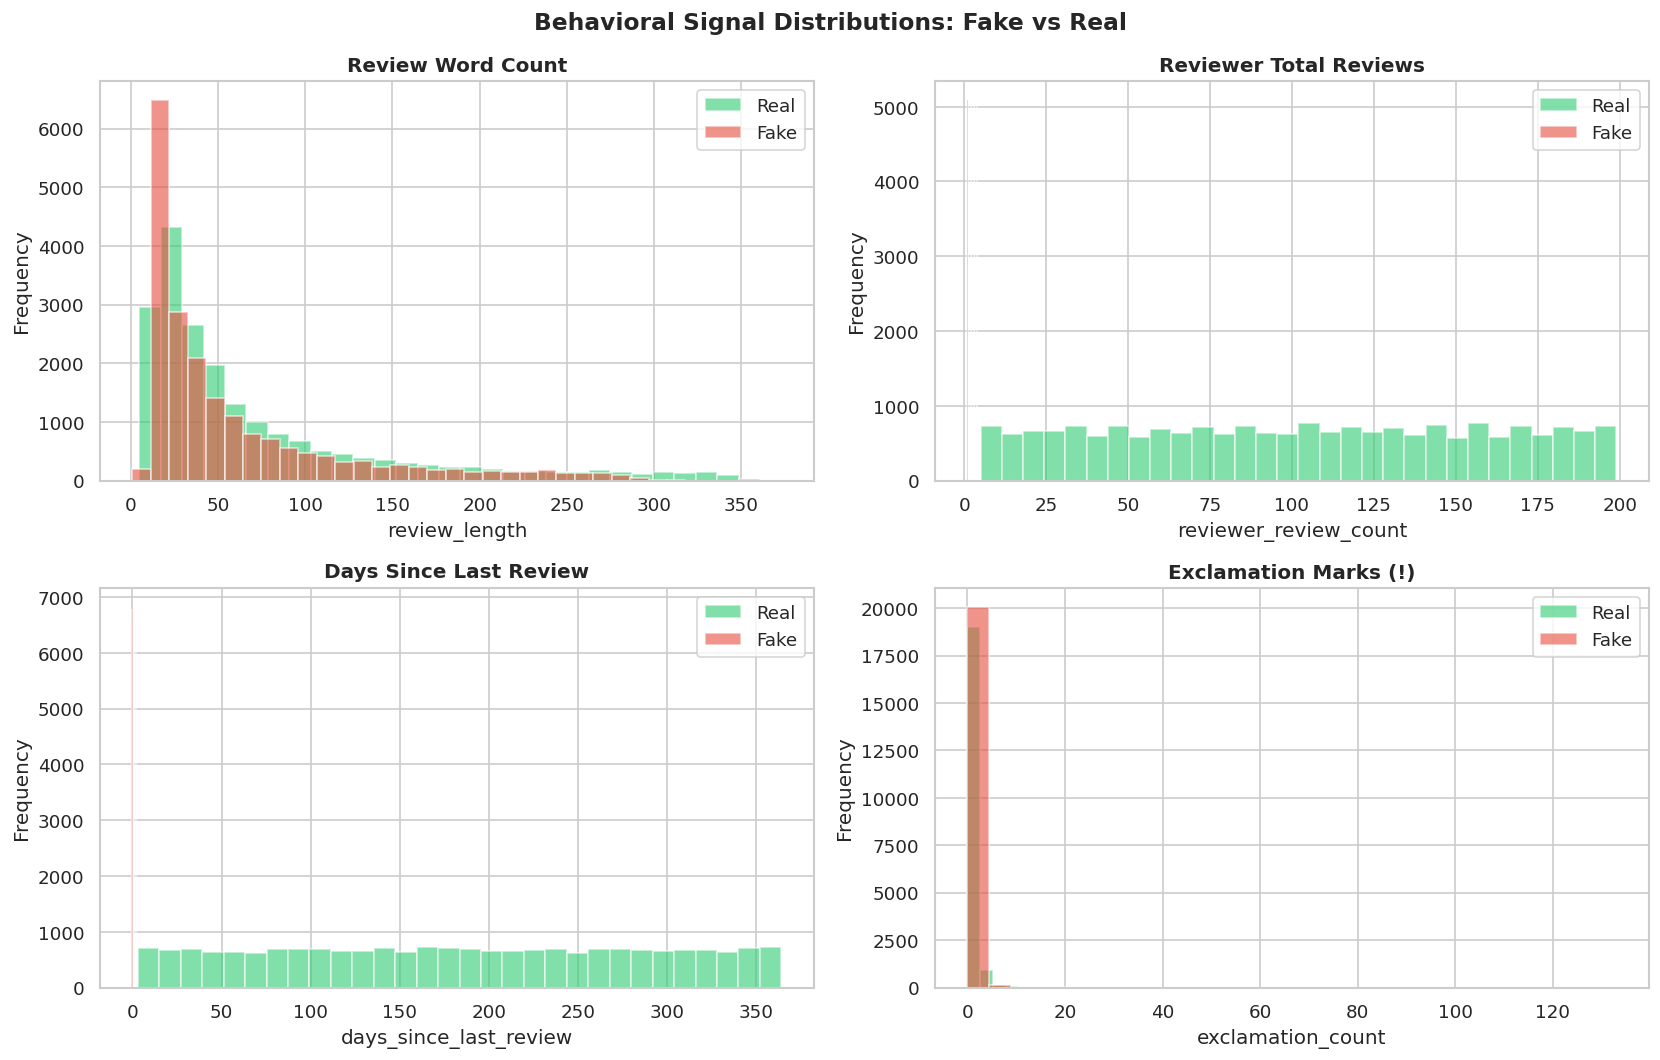

In [9]:
# --- 3.4 Behavioral Signal Distributions ---
behavioral_features = [
    ('review_length', 'Review Word Count'),
    ('reviewer_review_count', 'Reviewer Total Reviews'),
    ('days_since_last_review', 'Days Since Last Review'),
    ('exclamation_count', 'Exclamation Marks (!)')
]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()
palette = {0: '#2ecc71', 1: '#e74c3c'}

for ax, (feat, title) in zip(axes, behavioral_features):
    for label, name, color in [(0, 'Real', '#2ecc71'), (1, 'Fake', '#e74c3c')]:
        subset = df[df['label'] == label][feat]
        ax.hist(subset, bins=30, alpha=0.6, label=name, color=color, edgecolor='white')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend()
    ax.set_xlabel(feat)
    ax.set_ylabel('Frequency')

plt.suptitle('Behavioral Signal Distributions: Fake vs Real', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

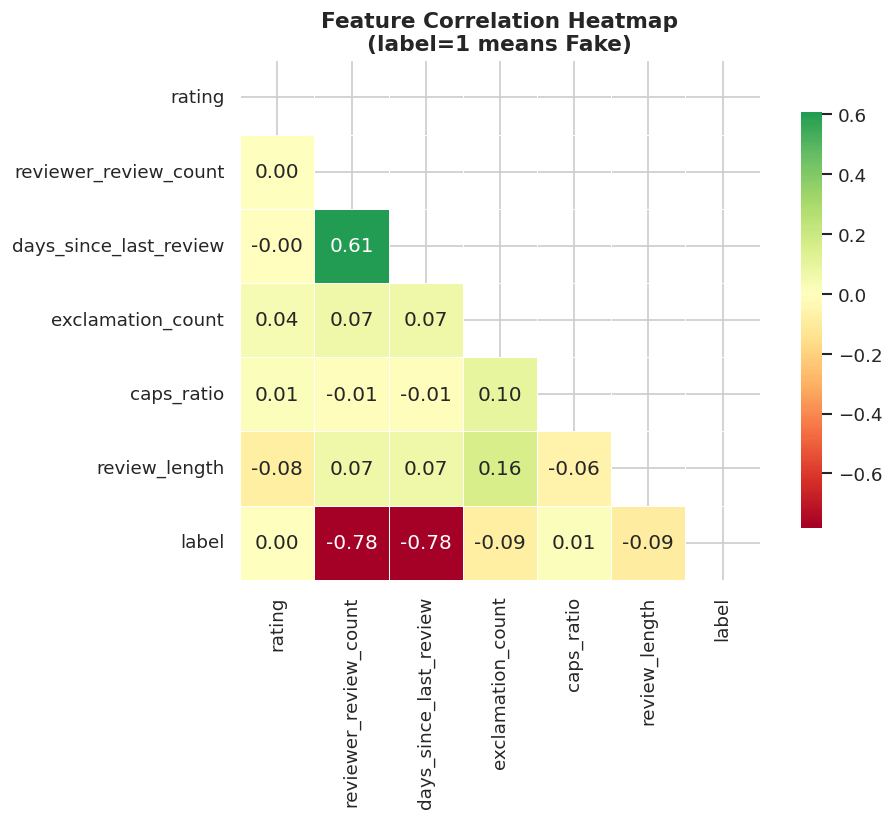


💡 Key correlations with 'label' (fake):
reviewer_review_count    -0.782
days_since_last_review   -0.779
review_length            -0.089
exclamation_count        -0.088
caps_ratio                0.012
rating                    0.003
Name: label, dtype: float64


In [10]:
# --- 3.5 Correlation Heatmap ---
numeric_cols = ['rating', 'reviewer_review_count', 'days_since_last_review',
                'exclamation_count', 'caps_ratio', 'review_length', 'label']

corr = df[numeric_cols].corr()

plt.figure(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, square=True, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Heatmap\n(label=1 means Fake)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print("\n💡 Key correlations with 'label' (fake):")
print(corr['label'].drop('label').sort_values(key=abs, ascending=False).round(3))

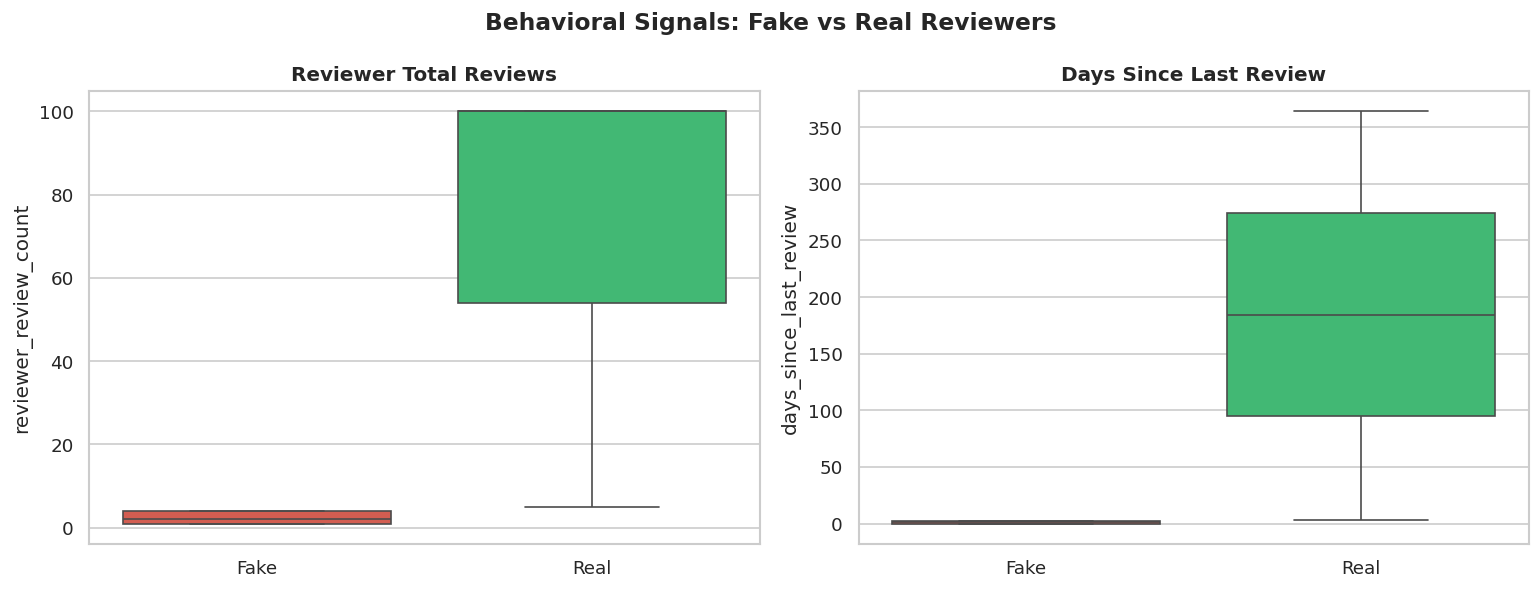


💡 Insight: Fake reviewers have far fewer total reviews and post in short time bursts


In [11]:
# --- 3.6 Boxplots: Reviewer Count & Days Since Last Review ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (feat, title, cap) in zip(axes, [
    ('reviewer_review_count', 'Reviewer Total Reviews', 100),
    ('days_since_last_review', 'Days Since Last Review', 365)
]):
    plot_df = df.copy()
    plot_df[feat] = plot_df[feat].clip(upper=cap)
    plot_df['Review Type'] = plot_df['label'].map({0: 'Real', 1: 'Fake'})
    sns.boxplot(data=plot_df, x='Review Type', y=feat, palette={'Real': '#2ecc71', 'Fake': '#e74c3c'}, ax=ax)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('')

plt.suptitle('Behavioral Signals: Fake vs Real Reviewers', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print("\n💡 Insight: Fake reviewers have far fewer total reviews and post in short time bursts")

---
## 🔧 Section 4: Feature Engineering

We create two sets of features:
- **Text Features**: TF-IDF on cleaned review text (vocabulary patterns)
- **Behavioral Features**: Rating, reviewer history, timing signals, writing style

In [12]:
# --- 4.1 Text Cleaning ---
def clean_text(text):
    """Lowercase, remove punctuation and numbers, strip extra spaces."""
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)  # keep only letters
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Basic stopwords (no NLTK needed)
STOPWORDS = set([
    'i', 'me', 'my', 'we', 'our', 'you', 'your', 'he', 'she', 'it',
    'they', 'them', 'this', 'that', 'these', 'those', 'is', 'are', 'was',
    'were', 'be', 'been', 'being', 'have', 'has', 'had', 'do', 'does',
    'did', 'will', 'would', 'could', 'should', 'may', 'might', 'shall',
    'can', 'a', 'an', 'the', 'and', 'but', 'or', 'for', 'with', 'at',
    'by', 'from', 'in', 'of', 'on', 'to', 'up', 'as', 'if', 'so',
    'about', 'into', 'through', 'during', 'before', 'after', 'than',
    'then', 'also', 'not', 'no', 'nor', 'very', 'just', 'here', 'there'
])

def remove_stopwords(text):
    return ' '.join(w for w in text.split() if w not in STOPWORDS)

df['cleaned_text'] = df['review_text'].apply(clean_text).apply(remove_stopwords)

print('Sample cleaned texts:')
for i in range(3):
    label = 'FAKE' if df.iloc[i]['label'] == 1 else 'REAL'
    print(f"  [{label}] {df.iloc[i]['cleaned_text'][:100]}...")

Sample cleaned texts:
  [FAKE] love well made sturdy comfortable love pretty...
  [FAKE] love great upgrade original ve mine couple years...
  [FAKE] pillow saved back love look feel pillow...


In [13]:
# --- 4.2 Additional Engineered Features ---

# Extreme rating flag: 1 or 5 stars
df['extreme_rating'] = df['rating'].apply(lambda r: 1 if r in [1, 5] else 0)

# New reviewer flag: fewer than 5 total reviews
df['new_reviewer'] = df['reviewer_review_count'].apply(lambda c: 1 if c < 5 else 0)

# Burst posting: reviewed very recently (same or next day)
df['burst_posting'] = df['days_since_last_review'].apply(lambda d: 1 if d <= 1 else 0)

# Repetition score: detect repeated phrases
def repetition_score(text):
    words = text.lower().split()
    if len(words) == 0:
        return 0
    unique_ratio = len(set(words)) / len(words)
    return round(1 - unique_ratio, 4)  # higher = more repetitive

df['repetition_score'] = df['review_text'].apply(repetition_score)

# Superlative density: words like 'best', 'worst', 'greatest', 'perfect'
superlatives = {'best', 'worst', 'greatest', 'perfect', 'amazing', 'terrible',
                'incredible', 'awful', 'fantastic', 'horrible', 'exceptional', 'outstanding'}
def superlative_density(text):
    words = text.lower().split()
    if not words:
        return 0
    return sum(1 for w in words if w in superlatives) / len(words)

df['superlative_density'] = df['review_text'].apply(superlative_density)

# All-caps word ratio
def caps_word_ratio(text):
    words = text.split()
    if not words:
        return 0
    return sum(1 for w in words if w.isupper() and len(w) > 1) / len(words)

df['caps_word_ratio'] = df['review_text'].apply(caps_word_ratio)

print('✅ Feature engineering complete. New features added:')
new_feats = ['extreme_rating', 'new_reviewer', 'burst_posting',
             'repetition_score', 'superlative_density', 'caps_word_ratio']
print(df[new_feats + ['label']].groupby('label').mean().round(3).rename(index={0: 'Real', 1: 'Fake'}))

✅ Feature engineering complete. New features added:
       extreme_rating  new_reviewer  burst_posting  repetition_score  \
label                                                                  
Real            0.659           0.0          0.000             0.175   
Fake            0.662           1.0          0.672             0.250   

       superlative_density  caps_word_ratio  
label                                        
Real                 0.003            0.010  
Fake                 0.003            0.007  


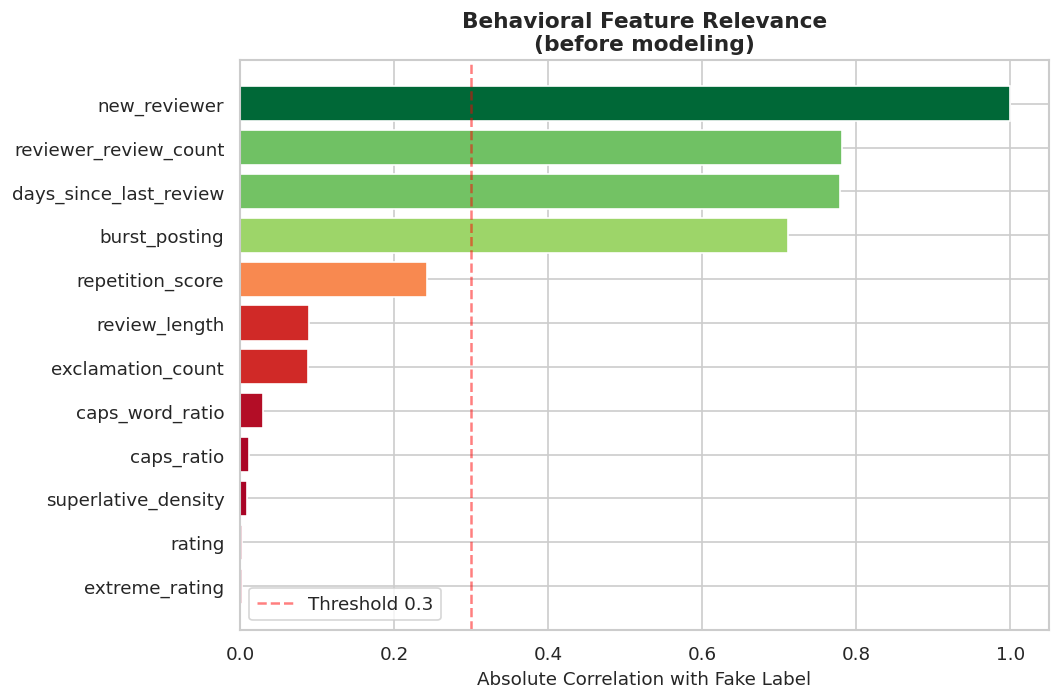

In [14]:
# --- 4.3 Feature Importance Preview (Behavioral) ---
behavior_features = [
    'rating', 'reviewer_review_count', 'days_since_last_review',
    'exclamation_count', 'caps_ratio', 'review_length',
    'extreme_rating', 'new_reviewer', 'burst_posting',
    'repetition_score', 'superlative_density', 'caps_word_ratio'
]

# Quick correlation with label
correlations = df[behavior_features + ['label']].corr()['label'].drop('label').abs().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(correlations.index, correlations.values,
               color=plt.cm.RdYlGn(correlations.values / correlations.values.max()),
               edgecolor='white')
ax.set_xlabel('Absolute Correlation with Fake Label', fontsize=11)
ax.set_title('Behavioral Feature Relevance\n(before modeling)', fontsize=13, fontweight='bold')
ax.axvline(0.3, color='red', linestyle='--', alpha=0.5, label='Threshold 0.3')
ax.legend()
plt.tight_layout()
plt.show()

---
## 🤖 Section 5: Model Training

We combine **TF-IDF text features** + **behavioral features** into a single feature matrix and train multiple classifiers.

In [15]:
# --- 5.1 Build Combined Feature Matrix ---

# TF-IDF on cleaned text
tfidf = TfidfVectorizer(
    max_features=500,
    ngram_range=(1, 2),  # unigrams + bigrams
    min_df=3,
    sublinear_tf=True    # dampen high frequencies
)
X_text = tfidf.fit_transform(df['cleaned_text'])

# Behavioral features
X_behavioral = csr_matrix(df[behavior_features].values.astype(float))

# Combine text + behavioral
X = hstack([X_text, X_behavioral])
y = df['label'].values

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f'Total features: {X.shape[1]} ({X_text.shape[1]} TF-IDF + {len(behavior_features)} behavioral)')
print(f'Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}')

Total features: 512 (500 TF-IDF + 12 behavioral)
Train size: 32345 | Test size: 8087


In [16]:
# --- 5.2 Train & Compare Multiple Models ---

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, C=1.0, random_state=SEED),
    'Naive Bayes': MultinomialNB(alpha=0.1),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=SEED)
}

results = {}
trained_models = {}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

print(f"{'Model':<25} {'CV Accuracy':>12} {'Test Accuracy':>14} {'ROC-AUC':>10}")
print('-' * 65)

for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy', n_jobs=-1)
    test_acc = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    results[name] = {
        'cv_accuracy': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'test_accuracy': test_acc,
        'roc_auc': roc_auc,
        'y_pred': y_pred,
        'y_prob': y_prob
    }
    print(f"{name:<25} {cv_scores.mean():.4f} ± {cv_scores.std():.3f}  {test_acc:.4f}         {roc_auc:.4f}")

best_model_name = max(results, key=lambda k: results[k]['roc_auc'])
print(f"\n🏆 Best model by ROC-AUC: {best_model_name}")

Model                      CV Accuracy  Test Accuracy    ROC-AUC
-----------------------------------------------------------------
Logistic Regression       0.9999 ± 0.000  1.0000         1.0000
Naive Bayes               0.9904 ± 0.002  0.9905         0.9931
Random Forest             1.0000 ± 0.000  1.0000         1.0000
Gradient Boosting         1.0000 ± 0.000  1.0000         1.0000

🏆 Best model by ROC-AUC: Logistic Regression


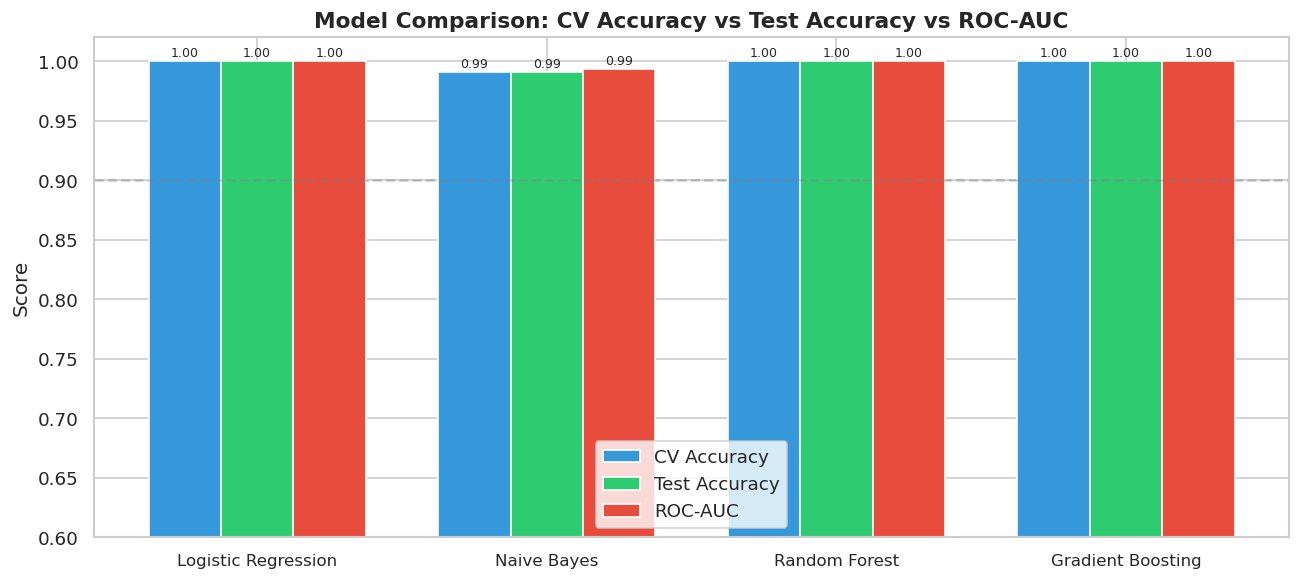

In [17]:
# --- 5.3 Model Comparison Bar Chart ---
fig, ax = plt.subplots(figsize=(11, 5))

model_names = list(results.keys())
cv_accs = [results[m]['cv_accuracy'] for m in model_names]
test_accs = [results[m]['test_accuracy'] for m in model_names]
roc_aucs = [results[m]['roc_auc'] for m in model_names]

x = np.arange(len(model_names))
width = 0.25

bars1 = ax.bar(x - width, cv_accs,  width, label='CV Accuracy',   color='#3498db', edgecolor='white')
bars2 = ax.bar(x,         test_accs, width, label='Test Accuracy', color='#2ecc71', edgecolor='white')
bars3 = ax.bar(x + width, roc_aucs,  width, label='ROC-AUC',       color='#e74c3c', edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=10)
ax.set_ylim(0.6, 1.02)
ax.set_ylabel('Score')
ax.set_title('Model Comparison: CV Accuracy vs Test Accuracy vs ROC-AUC', fontsize=13, fontweight='bold')
ax.legend()
ax.axhline(0.9, color='gray', linestyle='--', alpha=0.4, label='90% threshold')

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        ax.annotate(f'{bar.get_height():.2f}',
                    xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                    xytext=(0, 3), textcoords='offset points', ha='center', fontsize=7.5)

plt.tight_layout()
plt.show()

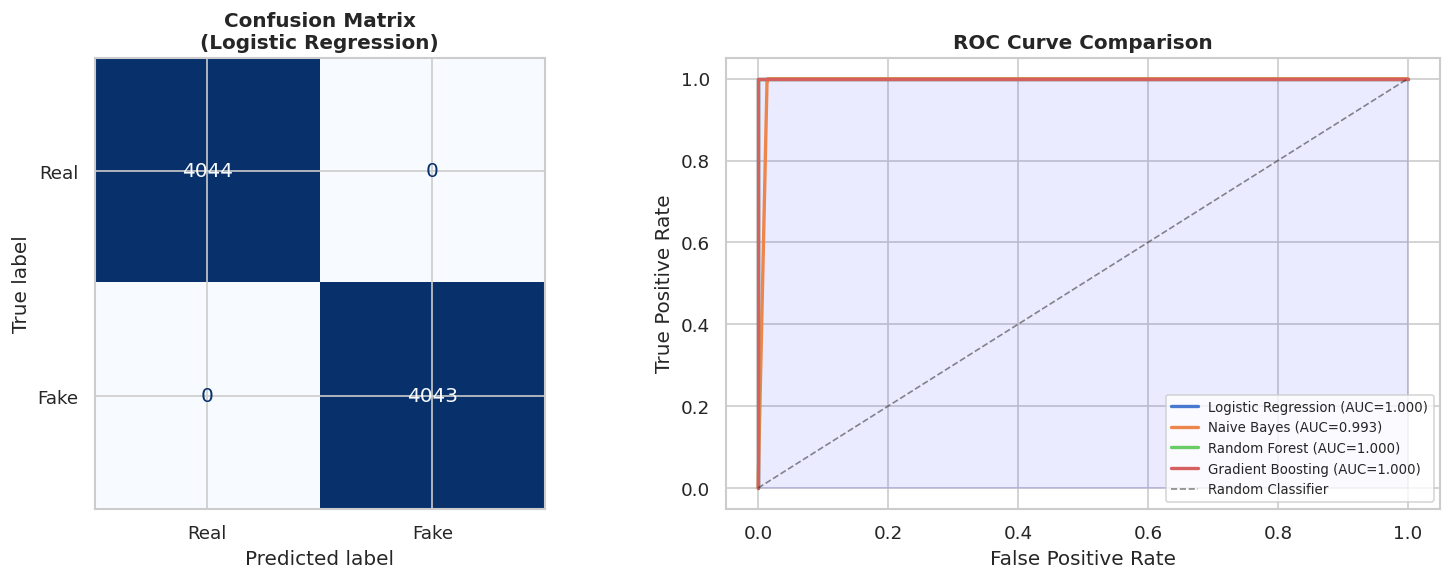


📋 Classification Report — Logistic Regression
              precision    recall  f1-score   support

        Real       1.00      1.00      1.00      4044
        Fake       1.00      1.00      1.00      4043

    accuracy                           1.00      8087
   macro avg       1.00      1.00      1.00      8087
weighted avg       1.00      1.00      1.00      8087



In [18]:
# --- 5.4 Best Model: Confusion Matrix + Classification Report ---
best = results[best_model_name]
best_model = trained_models[best_model_name]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, best['y_pred'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Real', 'Fake'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Confusion Matrix\n({best_model_name})', fontsize=12, fontweight='bold')

# ROC Curve - all models
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    axes[1].plot(fpr, tpr, label=f"{name} (AUC={res['roc_auc']:.3f})", lw=2)

axes[1].plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label='Random Classifier')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve Comparison', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=8, loc='lower right')
axes[1].fill_between(*roc_curve(y_test, best['y_prob'])[:2], alpha=0.08, color='blue')

plt.tight_layout()
plt.show()

print(f'\n📋 Classification Report — {best_model_name}')
print(classification_report(y_test, best['y_pred'], target_names=['Real', 'Fake']))

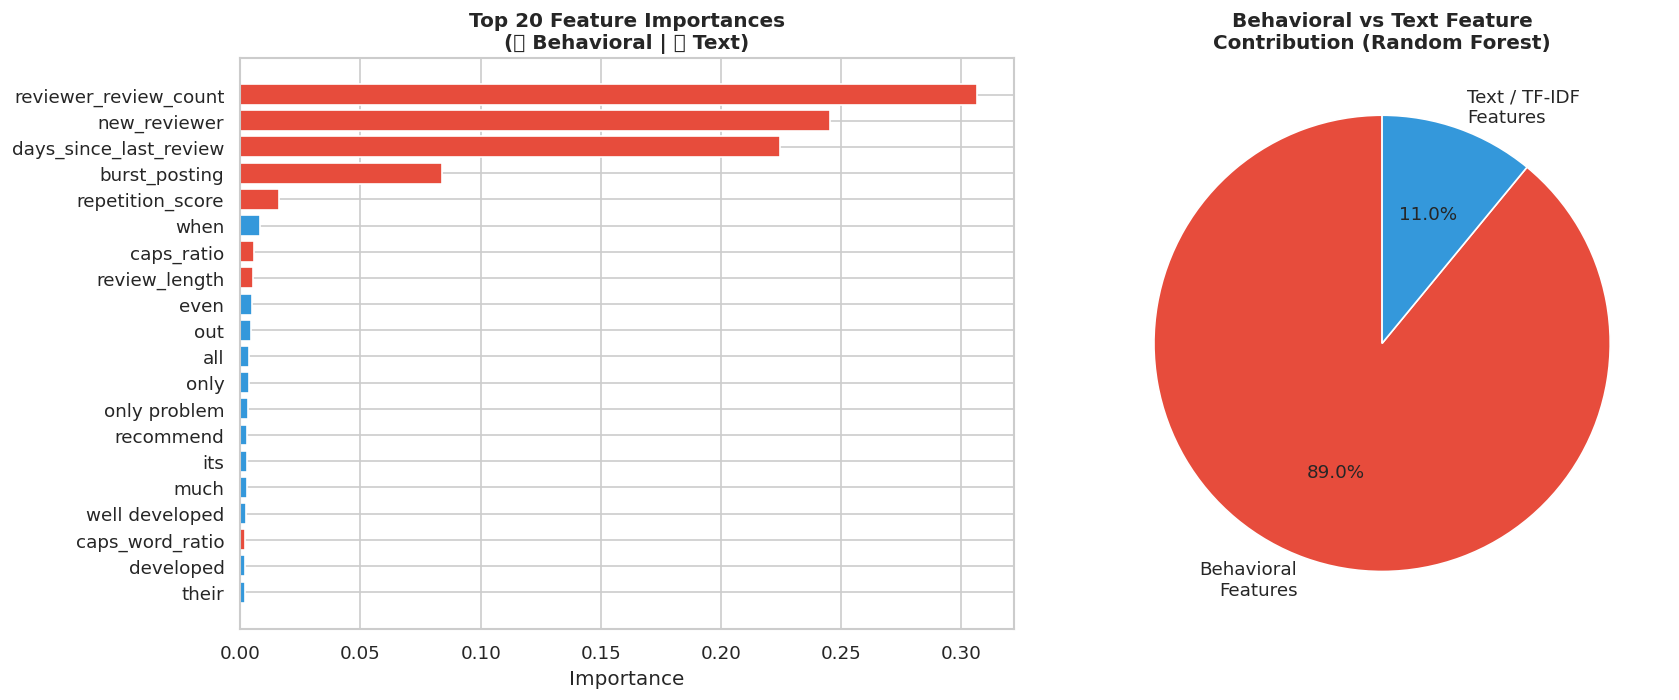

In [19]:
# --- 5.5 Feature Importance (Random Forest) ---
rf_model = trained_models['Random Forest']

# Feature names
tfidf_names = tfidf.get_feature_names_out().tolist()
all_feature_names = tfidf_names + behavior_features

importances = rf_model.feature_importances_
feat_df = pd.DataFrame({'feature': all_feature_names, 'importance': importances})
feat_df = feat_df.sort_values('importance', ascending=False)

# Top 20 overall
top20 = feat_df.head(20)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Top 20 features
colors_feat = ['#e74c3c' if f in behavior_features else '#3498db' for f in top20['feature']]
axes[0].barh(top20['feature'][::-1], top20['importance'][::-1], color=colors_feat[::-1], edgecolor='white')
axes[0].set_title('Top 20 Feature Importances\n(🔴 Behavioral | 🔵 Text)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Importance')

# Behavioral vs Text importance split
beh_imp = feat_df[feat_df['feature'].isin(behavior_features)]['importance'].sum()
txt_imp = feat_df[~feat_df['feature'].isin(behavior_features)]['importance'].sum()
axes[1].pie([beh_imp, txt_imp], labels=['Behavioral\nFeatures', 'Text / TF-IDF\nFeatures'],
            colors=['#e74c3c', '#3498db'], autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white'}, textprops={'fontsize': 11})
axes[1].set_title('Behavioral vs Text Feature\nContribution (Random Forest)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

---
## 🔍 Section 6: Prediction on New Reviews

Use the trained model to predict whether a custom review is fake or real.

In [20]:
def predict_review(review_text, rating, reviewer_review_count=10,
                   days_since_last_review=30, model_name='Random Forest'):
    """
    Predict whether a single review is FAKE or REAL.

    Parameters:
        review_text (str): The review to classify
        rating (int): Star rating given (1-5)
        reviewer_review_count (int): How many reviews this reviewer has posted total
        days_since_last_review (int): Days since their previous review
        model_name (str): Which model to use

    Returns:
        dict: prediction, confidence, and key signals
    """
    model = trained_models[model_name]

    # Clean text
    cleaned = remove_stopwords(clean_text(review_text))
    X_txt = tfidf.transform([cleaned])

    # Build behavioral features
    excl = review_text.count('!')
    caps_r = sum(1 for c in review_text if c.isupper()) / max(len(review_text), 1)
    length = len(review_text.split())
    extreme_r = 1 if rating in [1, 5] else 0
    new_rev = 1 if reviewer_review_count < 5 else 0
    burst = 1 if days_since_last_review <= 1 else 0
    rep_score = repetition_score(review_text)
    sup_density = superlative_density(review_text)
    caps_word_r = caps_word_ratio(review_text)

    beh_vals = [rating, reviewer_review_count, days_since_last_review,
                excl, caps_r, length, extreme_r, new_rev, burst,
                rep_score, sup_density, caps_word_r]

    X_beh = csr_matrix([beh_vals])
    X_input = hstack([X_txt, X_beh])

    prob = model.predict_proba(X_input)[0][1]
    pred = 'FAKE 🚨' if prob > 0.5 else 'REAL ✅'

    print(f"Review: \"{review_text[:80]}{'...' if len(review_text) > 80 else ''}\"")
    print(f"Prediction : {pred}")
    print(f"Fake Probability : {prob:.1%}")
    print(f"Model Used : {model_name}")
    print(f"Key Signals : Rating={rating}⭐ | Reviewer Reviews={reviewer_review_count} | "
          f"Days Since Last={days_since_last_review} | Exclamations={excl}")
    print('-' * 70)
    return {'prediction': pred, 'fake_probability': prob}


# --- Test Cases ---
print('=' * 70)
print('FAKE REVIEW DETECTOR — LIVE PREDICTIONS')
print('=' * 70)

predict_review(
    review_text="BEST RESTAURANT EVER!!!! Amazing amazing amazing!! HIGHLY RECOMMEND!!!",
    rating=5,
    reviewer_review_count=1,
    days_since_last_review=0
)

predict_review(
    review_text="The pasta was alright but a bit overpriced. Service was friendly though. Might return for lunch.",
    rating=3,
    reviewer_review_count=47,
    days_since_last_review=45
)

predict_review(
    review_text="Terrible place. Avoid at all costs. Worst experience of my life.",
    rating=1,
    reviewer_review_count=2,
    days_since_last_review=1
)

predict_review(
    review_text="Good spot for a quick coffee. Nothing exceptional but consistent quality and fair pricing.",
    rating=4,
    reviewer_review_count=88,
    days_since_last_review=20
)

FAKE REVIEW DETECTOR — LIVE PREDICTIONS
Review: "BEST RESTAURANT EVER!!!! Amazing amazing amazing!! HIGHLY RECOMMEND!!!"
Prediction : FAKE 🚨
Fake Probability : 100.0%
Model Used : Random Forest
Key Signals : Rating=5⭐ | Reviewer Reviews=1 | Days Since Last=0 | Exclamations=9
----------------------------------------------------------------------
Review: "The pasta was alright but a bit overpriced. Service was friendly though. Might r..."
Prediction : REAL ✅
Fake Probability : 0.0%
Model Used : Random Forest
Key Signals : Rating=3⭐ | Reviewer Reviews=47 | Days Since Last=45 | Exclamations=0
----------------------------------------------------------------------
Review: "Terrible place. Avoid at all costs. Worst experience of my life."
Prediction : FAKE 🚨
Fake Probability : 99.0%
Model Used : Random Forest
Key Signals : Rating=1⭐ | Reviewer Reviews=2 | Days Since Last=1 | Exclamations=0
----------------------------------------------------------------------
Review: "Good spot for a quick co

{'prediction': 'REAL ✅', 'fake_probability': np.float64(0.0)}